# Easy Run GCT and Cadence Analysis

This notebook explores how ground contact time (GCT) and cadence behave across easy runs. It uses the exported easy-run analysis CSV and focuses on the simplest mechanics questions:

- Do runs with higher cadence also show lower GCT?
- Do the metrics change over time as the easy-run score changes?
- Are there differences between short, standard, and long easy runs?

Cadence in this notebook is total steps per minute, and GCT comes from the exported average stance time in milliseconds.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.titlesize": 16,
})


In [7]:
csv_candidates = [
    Path("reports/easy/hr_improvement_analysis.csv"),
    Path("../reports/easy/hr_improvement_analysis.csv"),
]
csv_path = next((path for path in csv_candidates if path.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find reports/easy/hr_improvement_analysis.csv. Run the easy-run analysis pipeline first."
    )

df = pd.read_csv(csv_path, parse_dates=["date"])
easy_df = df.copy()

numeric_cols = [
    "avg_running_cadence",
    "avg_stance_time_ms",
    "easy_run_score",
    "aerobic_drift_pct",
    "pace_min_per_km",
    "duration_min",
    "steady_power_per_hr",
    "steady_avg_hr",
    "steady_hr_std",
]
for col in numeric_cols:
    if col in easy_df.columns:
        easy_df[col] = pd.to_numeric(easy_df[col], errors="coerce")

easy_df = easy_df.dropna(subset=["avg_running_cadence", "avg_stance_time_ms"]).copy()
easy_df["cadence_spm"] = easy_df["avg_running_cadence"]
easy_df["gct_ms"] = easy_df["avg_stance_time_ms"]
easy_df["cadence_gct_balance"] = easy_df["cadence_spm"] / easy_df["gct_ms"]

if "duration_bucket" not in easy_df.columns:
    easy_df["duration_bucket"] = "unknown"

easy_df["duration_bucket"] = easy_df["duration_bucket"].fillna("unknown").astype(str)
preferred_order = [bucket for bucket in ["short_easy", "standard_easy", "long_easy"] if bucket in easy_df["duration_bucket"].unique()]
remaining_order = sorted(bucket for bucket in easy_df["duration_bucket"].unique() if bucket not in preferred_order)
bucket_order = preferred_order + remaining_order
easy_df["duration_bucket"] = pd.Categorical(easy_df["duration_bucket"], categories=bucket_order, ordered=True)

pace_band_codes = pd.qcut(easy_df["pace_min_per_km"], q=3, labels=False, duplicates="drop")
pace_band_labels = {0: "fastest third", 1: "middle third", 2: "slowest third"}
easy_df["pace_band"] = pace_band_codes.map(pace_band_labels).fillna("unknown")
easy_df = easy_df.sort_values("date").reset_index(drop=True)
print(f"Loaded {len(easy_df)} easy runs from {csv_path}")
display(
    easy_df[[
        "date_str",
        "workout_title",
        "duration_bucket",
        "pace_band",
        "pace_min_per_km",
        "cadence_spm",
        "gct_ms",
        "aerobic_drift_pct",
        "easy_run_score",
    ]].tail(10)
)

Loaded 18 easy runs from ..\reports\easy\hr_improvement_analysis.csv


,date_str,workout_title,duration_bucket,pace_band,pace_min_per_km,cadence_spm,gct_ms,aerobic_drift_pct,easy_run_score
8,2026-05-14,75min Easy,long_easy,slowest third,7.49,166.0,282.6,6.45,55.8
9,2026-05-21,90min Easy,long_easy,middle third,7.34,168.0,280.1,7.31,54.3
10,2026-05-23,12K Run,long_easy,fastest third,6.96,168.0,277.4,4.63,65.1
11,2026-05-28,90min Easy,long_easy,slowest third,7.36,168.0,281.0,7.93,51.9
12,2026-06-02,75min Easy,long_easy,fastest third,7.32,164.0,285.7,6.40,61.5
13,2026-06-04,90min Easy,long_easy,slowest third,7.36,168.0,281.1,6.83,62.9
14,2026-06-13,10K Easy,long_easy,fastest third,7.32,164.0,284.1,5.68,64.1
15,2026-06-16,90min Easy,long_easy,fastest third,7.33,164.0,286.0,10.24,46.8
16,2026-06-23,90min Easy,long_easy,middle third,7.34,166.0,282.8,8.44,54.3
17,2026-06-30,90min Easy,long_easy,slowest third,7.36,166.0,283.4,6.41,63.9


## How to read the charts

There is no single international standard chart for cadence and GCT. The practical standard is to compare them at similar pace, because both metrics move with speed.

What to look for:
- Use cadence on the x-axis and GCT on the y-axis.
- Color or split the view by pace bands.
- Compare like-for-like easy runs instead of mixing all paces together.
- Treat your own normal range as the reference, not a universal target line.

A scatter plot with pace bands is the most useful starting point. A boxplot by pace band is the second most useful view because it shows whether cadence and GCT shift as pace changes.

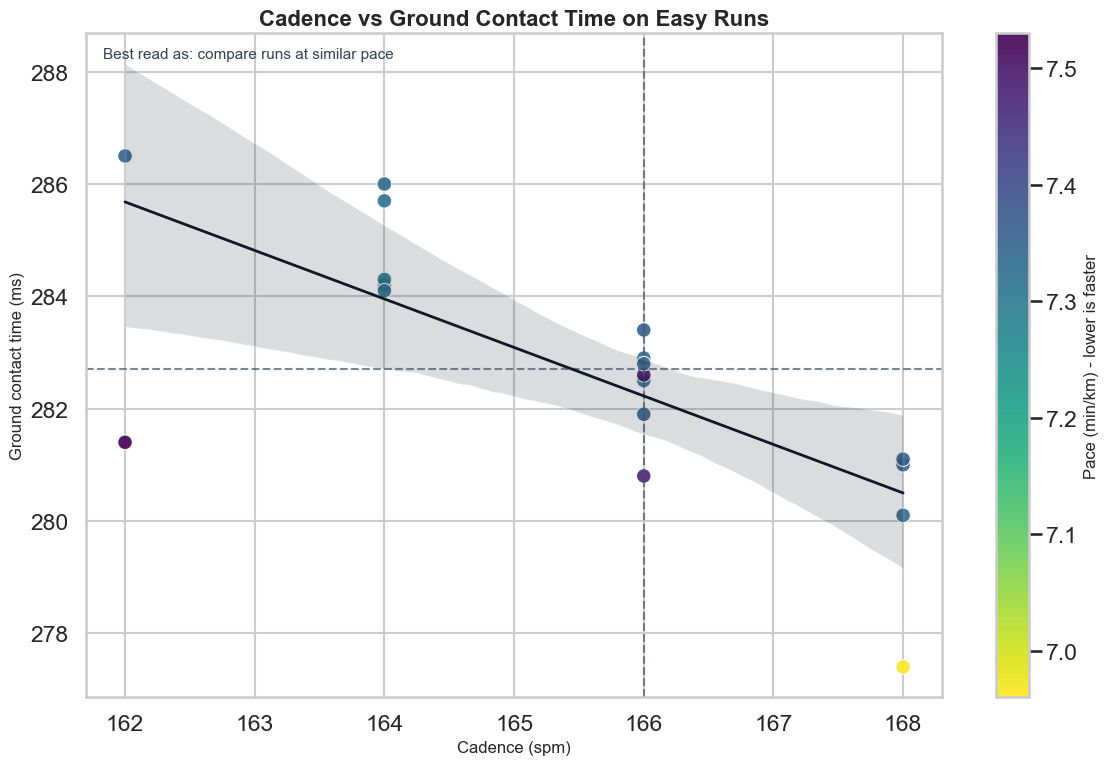

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    easy_df["cadence_spm"],
    easy_df["gct_ms"],
    c=easy_df["pace_min_per_km"],
    cmap="viridis_r",
    s=110,
    alpha=0.9,
    edgecolor="white",
    linewidth=0.8,
)

cadence_median = easy_df["cadence_spm"].median()
gct_median = easy_df["gct_ms"].median()
ax.axvline(cadence_median, color="#44546A", linestyle="--", linewidth=1.5, alpha=0.7)
ax.axhline(gct_median, color="#44546A", linestyle="--", linewidth=1.5, alpha=0.7)

sns.regplot(
    data=easy_df,
    x="cadence_spm",
    y="gct_ms",
    scatter=False,
    ax=ax,
    color="#111827",
    line_kws={"linewidth": 2},
)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Pace (min/km) - lower is faster")
ax.set_title("Cadence vs Ground Contact Time on Easy Runs")
ax.set_xlabel("Cadence (spm)")
ax.set_ylabel("Ground contact time (ms)")
ax.text(0.02, 0.98, "Best read as: compare runs at similar pace", transform=ax.transAxes, va="top", fontsize=11, color="#334155")
plt.tight_layout()
plt.show()

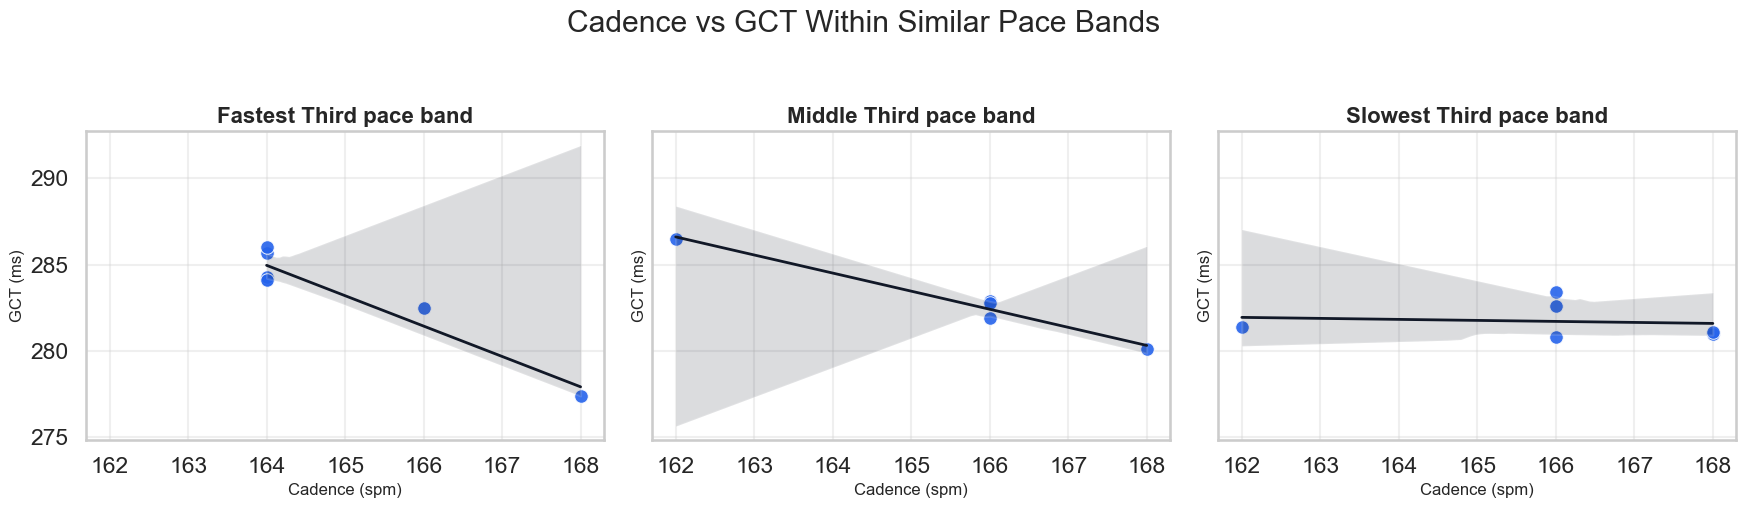

In [12]:
pace_band_order = [band for band in ["fastest third", "middle third", "slowest third"] if band in easy_df["pace_band"].unique()]
fig, axes = plt.subplots(1, len(pace_band_order), figsize=(6 * len(pace_band_order), 5), sharex=True, sharey=True)
if len(pace_band_order) == 1:
    axes = [axes]

for ax, band in zip(axes, pace_band_order):
    band_df = easy_df[easy_df["pace_band"] == band]
    ax.scatter(
        band_df["cadence_spm"],
        band_df["gct_ms"],
        s=95,
        alpha=0.9,
        edgecolor="white",
        linewidth=0.7,
        color="#2563EB",
    )
    if len(band_df) >= 2:
        sns.regplot(
            data=band_df,
            x="cadence_spm",
            y="gct_ms",
            scatter=False,
            ax=ax,
            color="#111827",
            line_kws={"linewidth": 2},
        )
    ax.set_title(f"{band.title()} pace band")
    ax.set_xlabel("Cadence (spm)")
    ax.set_ylabel("GCT (ms)")
    ax.grid(alpha=0.3)

plt.suptitle("Cadence vs GCT Within Similar Pace Bands", y=1.03)
plt.tight_layout()
plt.show()

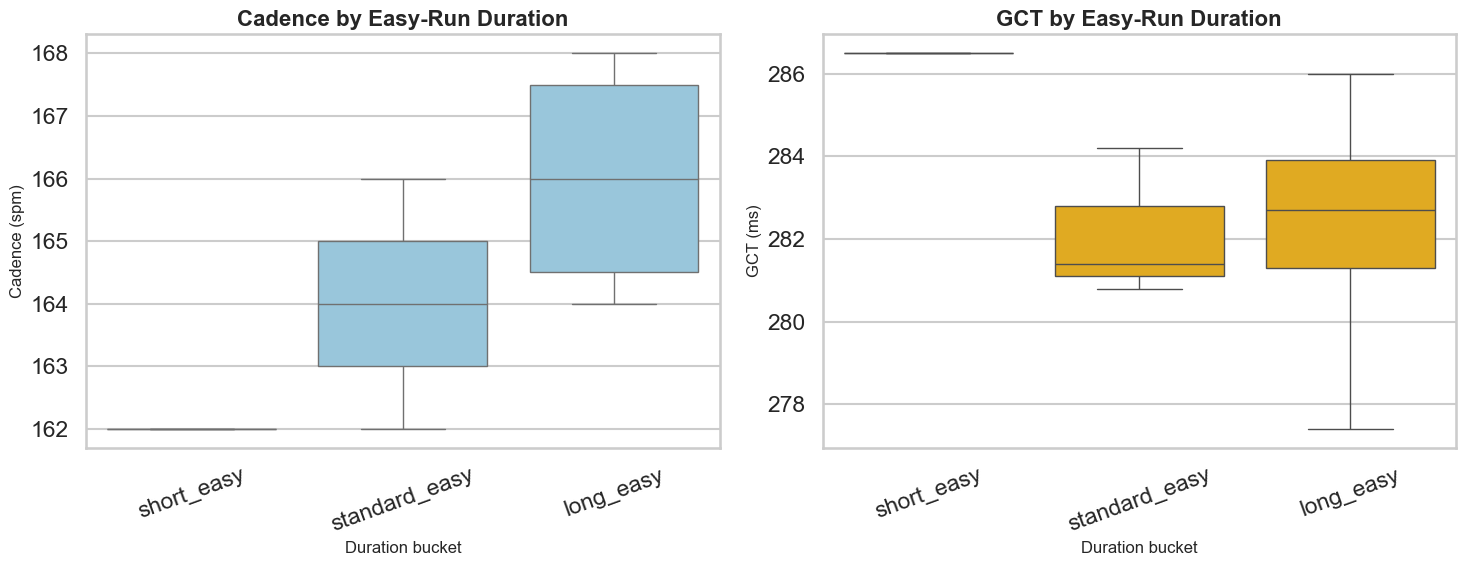

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

sns.boxplot(
    data=easy_df,
    x="pace_band",
    y="cadence_spm",
    order=pace_band_order,
    ax=axes[0],
    color="#8ecae6",
)
axes[0].set_title("Cadence by Pace Band")
axes[0].set_xlabel("Pace band")
axes[0].set_ylabel("Cadence (spm)")

sns.boxplot(
    data=easy_df,
    x="pace_band",
    y="gct_ms",
    order=pace_band_order,
    ax=axes[1],
    color="#ffb703",
)
axes[1].set_title("GCT by Pace Band")
axes[1].set_xlabel("Pace band")
axes[1].set_ylabel("GCT (ms)")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

Pace-band summary for cadence and GCT:


,pace_band,runs,pace_mean,cadence_mean,gct_mean,cadence_gct_corr,score_mean
0,fastest third,7,7.268571,164.857143,283.457143,-0.951812,58.100000
1,middle third,5,7.344000,165.600000,282.840000,-0.983623,54.580000
2,slowest third,6,7.428333,166.000000,281.716667,-0.122431,59.266667


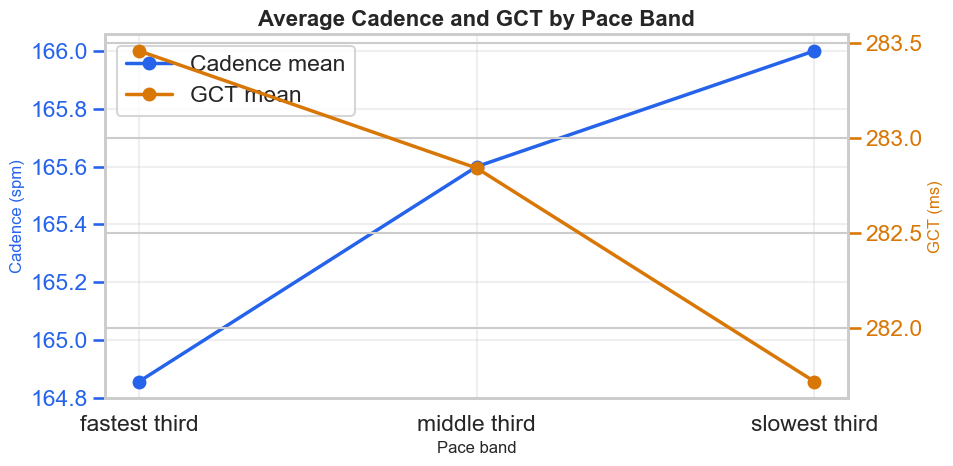

In [14]:
summary = (
    easy_df.groupby("pace_band", observed=True)
    .agg(
        runs=("pace_band", "size"),
        pace_mean=("pace_min_per_km", "mean"),
        cadence_mean=("cadence_spm", "mean"),
        gct_mean=("gct_ms", "mean"),
        cadence_gct_corr=("cadence_spm", lambda s: s.corr(easy_df.loc[s.index, "gct_ms"])),
        score_mean=("easy_run_score", "mean"),
    )
    .reindex(pace_band_order)
    .reset_index()
)

print("Pace-band summary for cadence and GCT:")
display(summary)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(summary["pace_band"], summary["cadence_mean"], marker="o", linewidth=2.5, color="#2563EB", label="Cadence mean")
ax2.plot(summary["pace_band"], summary["gct_mean"], marker="o", linewidth=2.5, color="#D97706", label="GCT mean")

ax1.set_title("Average Cadence and GCT by Pace Band")
ax1.set_xlabel("Pace band")
ax1.set_ylabel("Cadence (spm)", color="#2563EB")
ax2.set_ylabel("GCT (ms)", color="#D97706")
ax1.tick_params(axis="y", colors="#2563EB")
ax2.tick_params(axis="y", colors="#D97706")
ax1.grid(alpha=0.3)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="best")
plt.tight_layout()
plt.show()